# ITC101 - Lab 2
## Agents and Search - putting Unit 1 together

In Lab 1 you watched a computer find a route. This time you will explore **both halves of Unit 1**:

- **Part A - Agents:** watch a cleaning *agent* act in its environment, and see why a **model-based** agent (with memory) beats a **simple reflex** agent (no memory).
- **Part B - Search:** watch **BFS, DFS and A\*** search a map with walls, and see why a good **heuristic** makes A\* explore far less.
- **Part C - Reflection:** short questions linking what you saw to the theory.

**How to use it:** run cells top to bottom with **Shift+Enter**. Most cells just run. You only edit the lines marked `# <-- edit me` or the single `# TODO` in Part B. Nothing to install.


---
## Part A - Agents in action
Run the cell below. It drops some dirt on a grid and lets two agents clean it:
a **simple reflex** agent (moves at random, no memory) and a **model-based** agent
(remembers a plan and sweeps neatly). Compare how many steps each one needs.


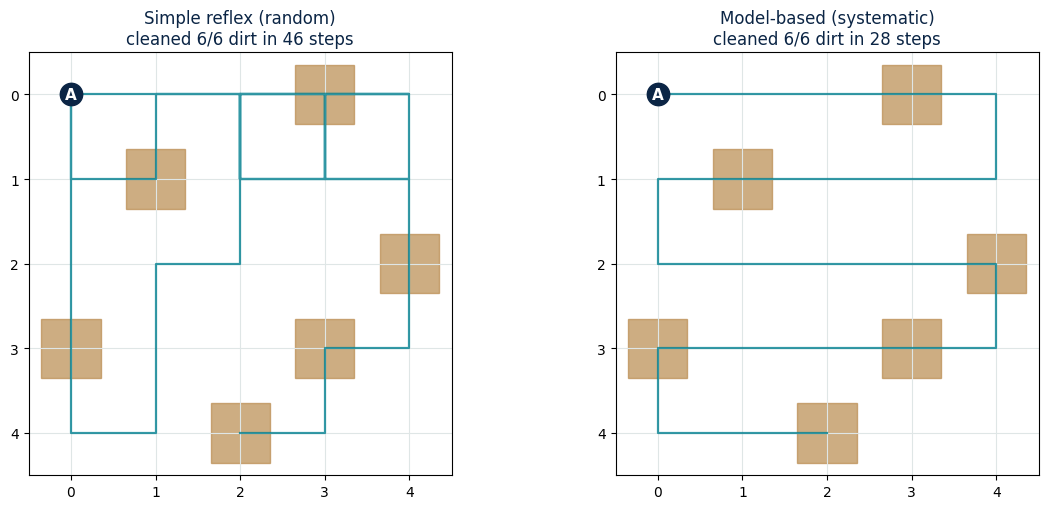

Simple reflex : 46 steps to clean 6 / 6
Model-based   : 28 steps to clean 6 / 6


In [1]:
# ===== PART A - RUN THIS CELL (do not change) =====
# A tiny "vacuum world": a grid with some dirty squares. A cleaning agent must
# clean them all. We will compare TWO agents from the lecture:
#   1) a SIMPLE REFLEX agent  - no memory, moves randomly
#   2) a MODEL-BASED agent    - remembers where it has been, sweeps neatly
import random
import matplotlib.pyplot as plt

def make_world(rows, cols, dirt_cells):
    return {'rows': rows, 'cols': cols, 'dirt': set(dirt_cells)}

def neighbours(pos, rows, cols):
    r, c = pos
    opts = [(r-1,c),(r+1,c),(r,c-1),(r,c+1)]
    return [(nr,nc) for nr,nc in opts if 0 <= nr < rows and 0 <= nc < cols]

# ---- Agent 1: simple reflex (react to NOW, no memory) ----
def simple_reflex_agent(world, max_steps=400, seed=1):
    random.seed(seed)
    rows, cols = world['rows'], world['cols']
    dirt = set(world['dirt']); total = len(dirt)
    pos = (0,0); path = [pos]; steps = 0
    while dirt and steps < max_steps:
        steps += 1
        if pos in dirt:                 # percept: "this square is dirty" -> suck
            dirt.discard(pos)
        else:                           # else: just move somewhere at random
            pos = random.choice(neighbours(pos, rows, cols))
            path.append(pos)
    return {'name':'Simple reflex (random)', 'steps':steps,
            'cleaned':total-len(dirt), 'total':total, 'path':path}

# ---- Agent 2: model-based (remembers a plan, sweeps every row) ----
def model_based_agent(world, max_steps=400):
    rows, cols = world['rows'], world['cols']
    dirt = set(world['dirt']); total = len(dirt)
    sweep = []                          # a tidy left-right, right-left snake path
    for r in range(rows):
        cs = range(cols) if r % 2 == 0 else range(cols-1, -1, -1)
        for c in cs: sweep.append((r,c))
    pos = sweep[0]; path = [pos]; steps = 0
    if pos in dirt: dirt.discard(pos); steps += 1
    for nxt in sweep[1:]:
        pos = nxt; steps += 1; path.append(pos)   # move to next square in the plan
        if pos in dirt: dirt.discard(pos); steps += 1
        if not dirt: break
    return {'name':'Model-based (systematic)', 'steps':steps,
            'cleaned':total-len(dirt), 'total':total, 'path':path}

def show_runs(world, results):
    fig, axes = plt.subplots(1, len(results), figsize=(6*len(results), 5.2))
    if len(results) == 1: axes = [axes]
    for ax, res in zip(axes, results):
        rows, cols = world['rows'], world['cols']
        ax.set_xlim(-0.5, cols-0.5); ax.set_ylim(rows-0.5, -0.5); ax.set_aspect('equal')
        ax.set_xticks(range(cols)); ax.set_yticks(range(rows)); ax.grid(True, color='#dfe6e6')
        for (r,c) in world['dirt']:      # dirt = small brown squares
            ax.add_patch(plt.Rectangle((c-0.35,r-0.35),0.7,0.7, color='#b98a4d', alpha=0.7))
        xs = [c for (r,c) in res['path']]; ys = [r for (r,c) in res['path']]
        ax.plot(xs, ys, color='#028090', lw=1.6, alpha=0.8, zorder=2)
        ax.scatter([0],[0], s=260, color='#0B2545', zorder=3)     # start
        ax.text(0,0,'A', color='white', ha='center', va='center', fontsize=11, fontweight='bold', zorder=4)
        ax.set_title(f"{res['name']}\ncleaned {res['cleaned']}/{res['total']} dirt in {res['steps']} steps",
                     fontsize=12, color='#0B2545')
    plt.tight_layout(); plt.show()

# default world: 5x5 grid, 6 dirty squares
WORLD = make_world(5, 5, [(0,3),(1,1),(2,4),(3,0),(3,3),(4,2)])
r1 = simple_reflex_agent(WORLD)
r2 = model_based_agent(WORLD)
show_runs(WORLD, [r1, r2])
print("Simple reflex :", r1['steps'], "steps to clean", r1['cleaned'], "/", r1['total'])
print("Model-based   :", r2['steps'], "steps to clean", r2['cleaned'], "/", r2['total'])


**Experiment:** change the grid or the dirt and run again. Does the random agent get *much* worse as the grid grows? Why might that be?

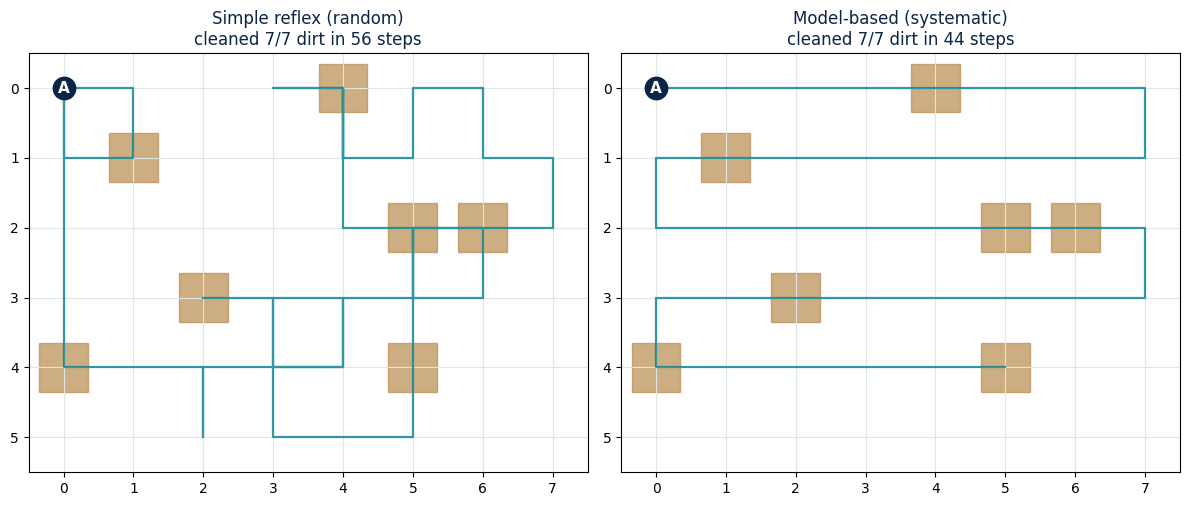

In [3]:
# ===== PART A - YOUR TURN =====
# Change the grid size or the dirty squares below and run again.
# Watch how the two agents' step-counts change. (The 'A' marks where the agent starts.)
rows, cols = 6, 8                                  # <-- edit me (try 6, 8 ...)
dirt = [(0,4),(1,1),(2,5),(3,2),(4,0),(4,5),(2,6)]        # <-- edit me (add/remove squares)

world2 = make_world(rows, cols, dirt)
show_runs(world2, [simple_reflex_agent(world2), model_based_agent(world2)])


---
## Part B - Search on a map with walls
Now the agent must get from **S** to **G** around some walls. First watch the two
**blind** searches. Notice *how much of the map each one lights up* (explores) and
*how long the path is* that each returns.


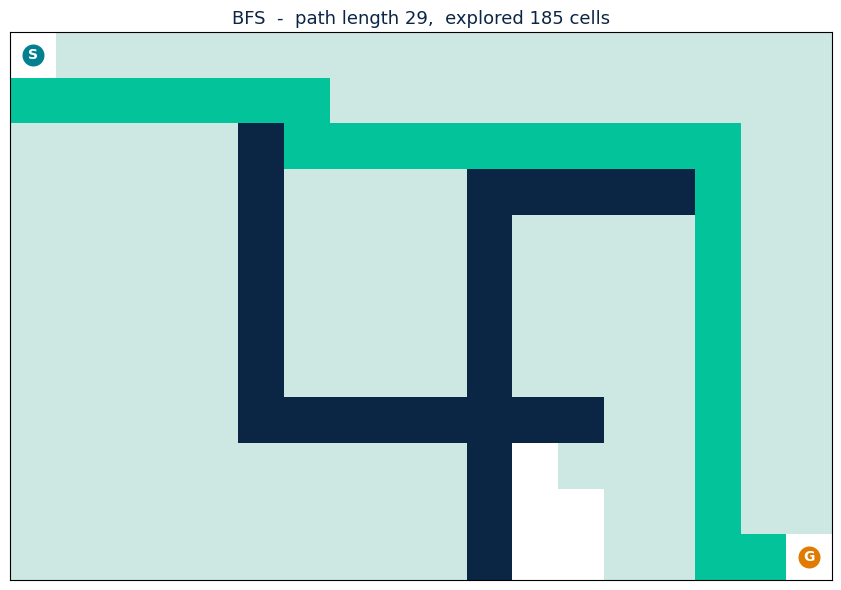

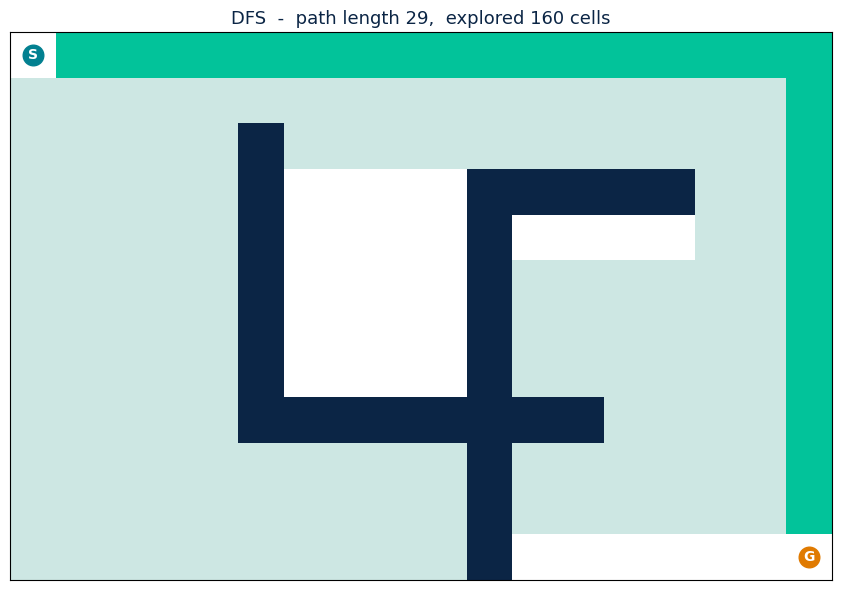

Light cells = places the search looked.  Green cells = the path it returned.


In [4]:
# ===== PART B - RUN THIS CELL (do not change) =====
# Now a bigger map with WALLS. The agent must travel from S (top-left) to G
# (bottom-right). We will watch three search methods explore the map:
#   BFS and DFS (uninformed / blind)   and later   A* (informed / uses a hint)
import heapq
import matplotlib.pyplot as plt
import numpy as np

ROWS, COLS = 12, 18
walls = set()
for r in range(2, 9):  walls.add((r, 5))      # a wall with a gap at the bottom
for r in range(4, 12): walls.add((r, 10))     # another wall with a gap at the top
for c in range(10, 15): walls.add((3, c))     # a horizontal wall
for c in range(6, 13):  walls.add((8, c))     # another horizontal wall
START, GOAL = (0, 0), (ROWS-1, COLS-1)
walls.discard(START); walls.discard(GOAL)

def nbrs(pos):
    r, c = pos
    out = []
    for nr, nc in [(r-1,c),(r+1,c),(r,c-1),(r,c+1)]:
        if 0 <= nr < ROWS and 0 <= nc < COLS and (nr,nc) not in walls:
            out.append((nr,nc))
    return out

def rebuild(came, goal):
    p, cur = [], goal
    while cur is not None: p.append(cur); cur = came.get(cur)
    return p[::-1]

def bfs(start, goal):
    from collections import deque
    fr = deque([start]); came = {start: None}; explored = []
    while fr:
        n = fr.popleft(); explored.append(n)
        if n == goal: break
        for m in nbrs(n):
            if m not in came: came[m] = n; fr.append(m)
    return rebuild(came, goal), explored

def dfs(start, goal):
    stack = [start]; came = {start: None}; explored = []; seen = set()
    while stack:
        n = stack.pop()
        if n in seen: continue
        seen.add(n); explored.append(n)
        if n == goal: break
        for m in nbrs(n):
            if m not in came: came[m] = n
            if m not in seen: stack.append(m)
    return rebuild(came, goal), explored

def draw_grid(explored, path, title):
    grid = np.zeros((ROWS, COLS))
    for (r,c) in walls: grid[r,c] = 1
    for (r,c) in explored:
        if (r,c) not in (START, GOAL): grid[r,c] = 2
    for (r,c) in path:
        if (r,c) not in (START, GOAL): grid[r,c] = 3
    from matplotlib.colors import ListedColormap
    cmap = ListedColormap(['#FFFFFF', '#0B2545', '#CDE7E3', '#02C39A'])
    plt.figure(figsize=(9, 6))
    plt.imshow(grid, cmap=cmap, vmin=0, vmax=3)
    plt.scatter([START[1]],[START[0]], s=220, color='#028090'); plt.text(START[1],START[0],'S',color='white',ha='center',va='center',fontweight='bold')
    plt.scatter([GOAL[1]],[GOAL[0]], s=220, color='#e07a00'); plt.text(GOAL[1],GOAL[0],'G',color='white',ha='center',va='center',fontweight='bold')
    plt.title(title, fontsize=13, color='#0B2545'); plt.xticks([]); plt.yticks([]); plt.tight_layout(); plt.show()

bpath, bexp = bfs(START, GOAL)
draw_grid(bexp, bpath, f"BFS  -  path length {len(bpath)},  explored {len(bexp)} cells")
dpath, dexp = dfs(START, GOAL)
draw_grid(dexp, dpath, f"DFS  -  path length {len(dpath)},  explored {len(dexp)} cells")
print("Light cells = places the search looked.  Green cells = the path it returned.")


---
### The hint that makes A\* smart
BFS and DFS are **blind** - they have no idea which way the goal is. A\* adds a **heuristic** `h`: a cheap guess of how far a cell is from the goal.

On a grid, a perfect cheap guess is the **Manhattan distance** - how many rows plus how many columns away the goal is (ignoring walls). Complete the one line below, then run it.


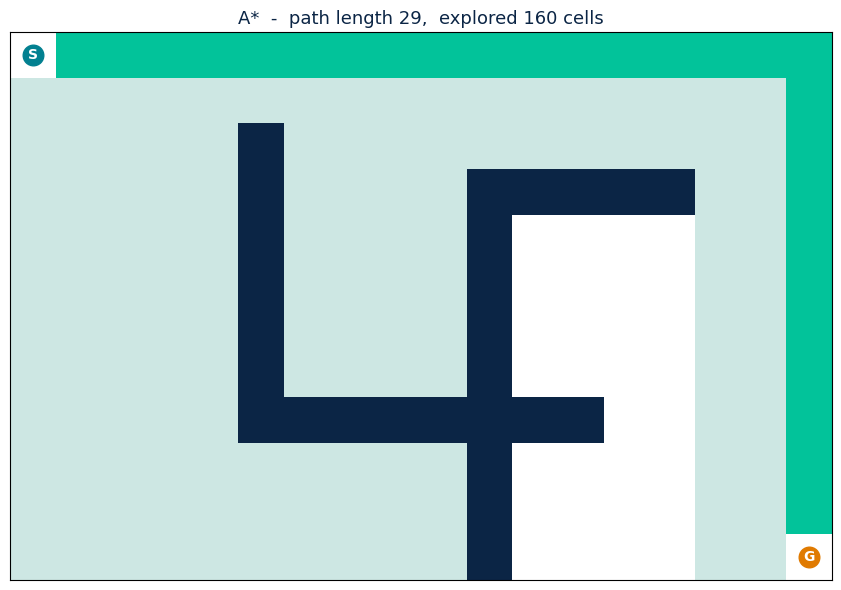

PASS - A* found a shortest path (29 cells) but explored only 160 cells vs BFS's 185. The hint saved a lot of searching!


In [5]:
# ===== PART B - complete ONE line, then run =====
def manhattan(a, b):
    # a and b are (row, col). Manhattan distance = |row diff| + |col diff|.
    # TODO: return abs(a[0]-b[0]) + abs(a[1]-b[1])
    return abs(a[0]-b[0]) + abs(a[1]-b[1])        # <-- replace this line

def astar(start, goal):
    fr = [(manhattan(start,goal), 0, start)]     # (f = g + h, g, cell)
    came = {start: None}; g = {start: 0}; explored = []
    while fr:
        _, gc, n = heapq.heappop(fr); explored.append(n)
        if n == goal: break
        for m in nbrs(n):
            ng = g[n] + 1
            if m not in g or ng < g[m]:
                g[m] = ng; came[m] = n
                heapq.heappush(fr, (ng + manhattan(m, goal), ng, m))
    return rebuild(came, goal), explored

apath, aexp = astar(START, GOAL)
draw_grid(aexp, apath, f"A*  -  path length {len(apath)},  explored {len(aexp)} cells")

# --- self check ---
bpath, bexp = bfs(START, GOAL)
if manhattan((0,0),(3,4)) == 7 and len(apath) == len(bpath):
    print(f"PASS - A* found a shortest path ({len(apath)} cells) but explored only "
          f"{len(aexp)} cells vs BFS's {len(bexp)}. The hint saved a lot of searching!")
else:
    print("Not quite - check your manhattan() TODO. It should return |row diff| + |col diff|.")


**Experiment:** add a wall or move S/G above, then re-run. Which method keeps finding the shortest path? Which one explores the fewest cells?

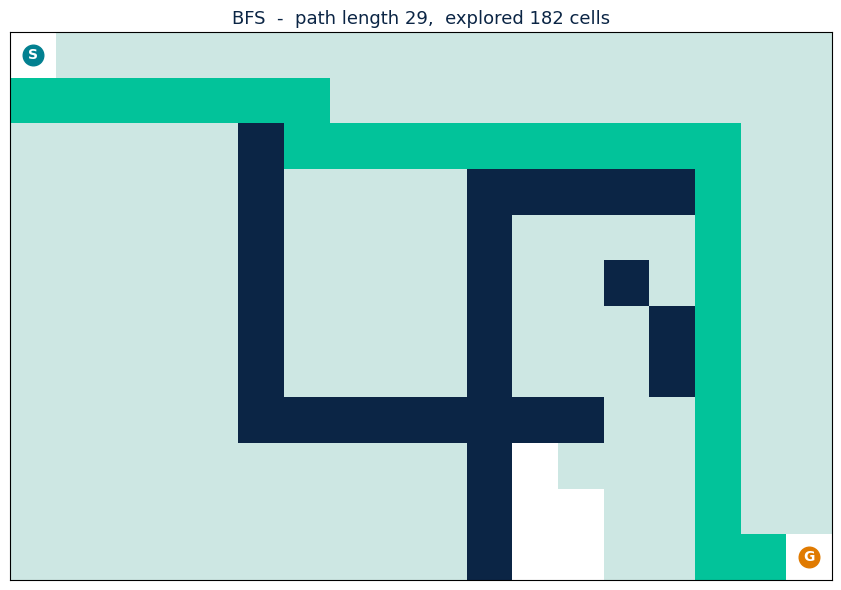

BFS  path  29  explored 182


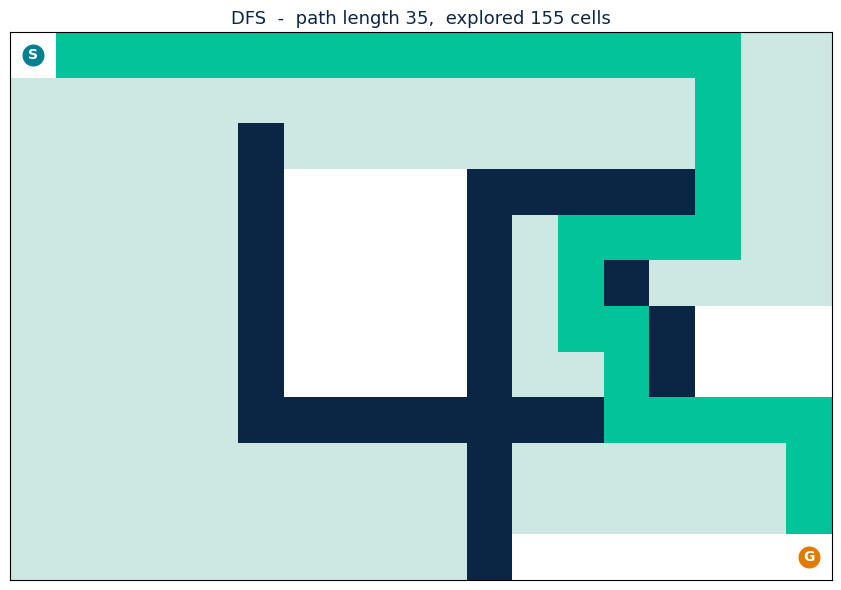

DFS  path  35  explored 155


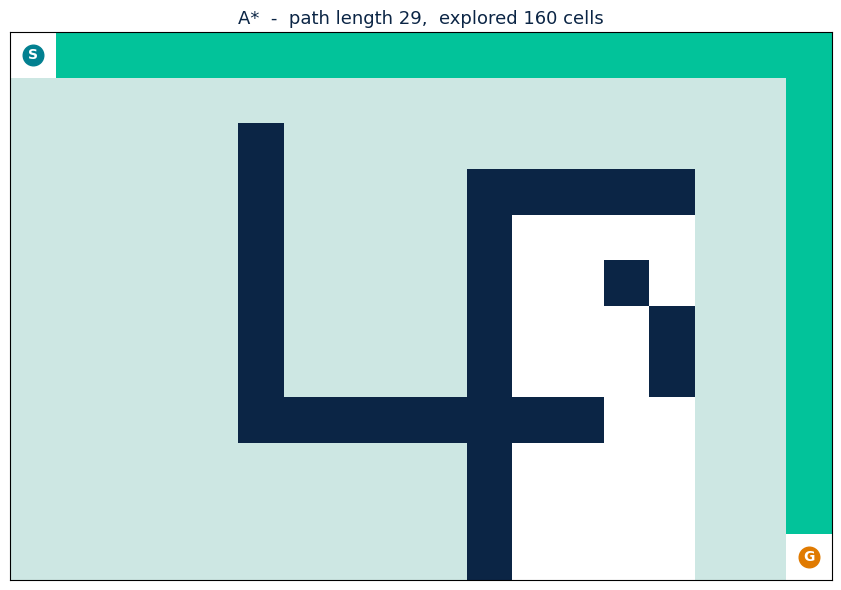

A*   path  29  explored 160


In [7]:
# ===== PART B - YOUR TURN =====
# Add a wall, or move the start/goal, then re-run all three searches and compare.
walls.add((6, 14))          # <-- example: add a wall. Try adding a few more.
walls.add((7, 14))
walls.add((5,13))
# START = (0, 5)            # <-- (optional) uncomment to move the start
# GOAL  = (11, 0)           # <-- (optional) uncomment to move the goal
walls.discard(START); walls.discard(GOAL)

for name, fn in [("BFS", bfs), ("DFS", dfs), ("A*", astar)]:
    p, e = fn(START, GOAL)
    draw_grid(e, p, f"{name}  -  path length {len(p)},  explored {len(e)} cells")
    print(f"{name:4} path {len(p):3}  explored {len(e):3}")


---
## Part C - Reflection  (answer in a few words each - double-click to edit)

**Agents**
1. Which agent cleaned the dirt in fewer steps - the simple reflex or the model-based one? Why does *memory* help?  
   -> Model-based agent cleaned the dirt in fewer steps because of memory as it remembers the places it has already visited, so it avoids unnecessary movement.

2. The lecture called these "simple reflex" and "model-based" agents. In one line, what is the key difference between them?  
   -> A simple reflex agent only reacts to what it sees right now (no memory) whereas model-based agent uses memory to make better decisions.

**Search**
3. Between BFS and DFS, which returned the **shortest** path? Which one **wandered** and gave a long path?  
   -> BFS returned the shortest path but DFS explored deeper before coming back, so it took a longer path.

4. A\* explored far fewer cells than BFS but still found a shortest path. What did the **heuristic `h`** do to make that happen?  
   -> The heuristic (h) estimated how close each position was to the goal. This helped A* choose better paths and explore fewer cells.

5. In real GPS navigation, what would the heuristic `h` represent?  
   -> In real GPS navigation, heuristic 'h' is an estimate of the remaining distance or travel time to the destination. It helps find the best route faster.

**Submit:** `File -> Download -> Download .ipynb` and upload to the class portal.
